# Load dataset

In [406]:
import pandas as pd

df = pd.read_json(
    "../data/arxiv-metadata-oai-snapshot.json",
    lines=True,
    nrows=10000
)

df.head()

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,None,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,None,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,None,physics.gen-ph,None,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,None,math.CO,None,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,None,math.CA math.FA,None,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


# How many papers?

In [52]:
df.shape

(10000, 14)

In [204]:
df.shape[0]

10000

In [203]:
df.columns

Index(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi',
       'report-no', 'categories', 'license', 'abstract', 'versions',
       'update_date', 'authors_parsed'],
      dtype='object')

# loc vs iloc

In [128]:
df.loc[0]

id                                                         704.0001
submitter                                            Pavel Nadolsky
authors           C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...
title             Calculation of prompt diphoton production cros...
comments                    37 pages, 15 figures; published version
journal-ref                                Phys.Rev.D76:013009,2007
doi                                      10.1103/PhysRevD.76.013009
report-no                                          ANL-HEP-PR-07-12
categories                                                   hep-ph
license                                                        None
abstract            A fully differential calculation in perturba...
versions          [{'version': 'v1', 'created': 'Mon, 2 Apr 2007...
update_date                                              2008-11-26
authors_parsed    [[Balázs, C., ], [Berger, E. L., ], [Nadolsky,...
Name: 0, dtype: object

In [127]:
df.iloc[0]

id                                                         704.0001
submitter                                            Pavel Nadolsky
authors           C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...
title             Calculation of prompt diphoton production cros...
comments                    37 pages, 15 figures; published version
journal-ref                                Phys.Rev.D76:013009,2007
doi                                      10.1103/PhysRevD.76.013009
report-no                                          ANL-HEP-PR-07-12
categories                                                   hep-ph
license                                                        None
abstract            A fully differential calculation in perturba...
versions          [{'version': 'v1', 'created': 'Mon, 2 Apr 2007...
update_date                                              2008-11-26
authors_parsed    [[Balázs, C., ], [Berger, E. L., ], [Nadolsky,...
Name: 0, dtype: object

# How many unique categories?

In [122]:
df["categories"].str.split().explode().value_counts().shape[0]

143

In [123]:
df["categories"].str.split().explode().nunique()

143

# Top 10 categories

In [148]:
df["categories"].str.split().explode().head(10)

0               hep-ph
1              math.CO
1                cs.CG
2       physics.gen-ph
3              math.CO
4              math.CA
4              math.FA
5    cond-mat.mes-hall
6                gr-qc
7    cond-mat.mtrl-sci
Name: categories, dtype: object

In [149]:
df["categories"].str.split().explode().value_counts().head(10)

categories
astro-ph              2064
hep-th                 996
hep-ph                 901
quant-ph               672
gr-qc                  558
cond-mat.stat-mech     445
cond-mat.mtrl-sci      444
math-ph                436
math.MP                436
cond-mat.str-el        419
Name: count, dtype: int64

# Papers per year

In [408]:
df["update_date"] = pd.to_datetime(df["update_date"])

df["update_date"].dt.year.value_counts().sort_index()

update_date
2007    3073
2008    2061
2009    3033
2010     354
2011     322
2012     150
2013      82
2014     118
2015     302
2016     180
2017      46
2018      28
2019     129
2020      18
2021      14
2022      14
2023       9
2024       6
2025       9
2026      52
Name: count, dtype: int64

# Top authors

In [178]:
df["authors"].str.split().explode().value_counts().head()

authors
and    3761
A.     1975
M.     1814
J.     1528
S.     1335
Name: count, dtype: int64

In [199]:
top_authors = (
    df["authors"]
    .str.replace(" and ", ", ", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

top_authors

authors
                            803
2)                           88
et al                        59
3)                           35
Germany)                     28
Tshilidzi Marwala            25
Damien Chablat (IRCCyN)      25
H. Vincent Poor              25
Italy                        24
Philippe Wenger (IRCCyN)     22
Name: count, dtype: int64

In [235]:
df["authors_parsed"]

0       [[Balázs, C., ], [Berger, E. L., ], [Nadolsky,...
1                [[Streinu, Ileana, ], [Theran, Louis, ]]
2                                      [[Pan, Hongjun, ]]
3                                     [[Callan, David, ]]
4       [[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]
                              ...                        
9995      [[Iyer, Kartik K, ], [Sampathkumaran, E. V., ]]
9996                                    [[Reffert, S., ]]
9997                                  [[Lieblich, Max, ]]
9998    [[Coffi-Nketsia, Barben-Jean, ], [Haddad, Labi...
9999    [[Coulbois, Thierry, , LATP], [Hilion, Arnaud,...
Name: authors_parsed, Length: 10000, dtype: object

In [233]:
df["authors_parsed"].iloc[0]

[['Balázs', 'C.', ''],
 ['Berger', 'E. L.', ''],
 ['Nadolsky', 'P. M.', ''],
 ['Yuan', 'C. -P.', '']]

In [212]:
type(df["authors_parsed"].iloc[0])

list

In [458]:
authors = (
    df["authors_parsed"]
    .explode()
    .apply(lambda x: f"{x[1]} {x[0]}".strip())
)

authors.head()

0         C. Balázs
0      E. L. Berger
0    P. M. Nadolsky
0       C. -P. Yuan
1    Ileana Streinu
Name: authors_parsed, dtype: object

In [231]:
authors.value_counts().head()

authors_parsed
Damien Chablat       32
H. Vincent Poor      27
Tshilidzi Marwala    25
Philippe Wenger      23
Yusuke Sasano        18
Name: count, dtype: int64

# Missing value analysis

This section explores the completeness of the dataset by identifying missing values and calculating the percentage of missing data for each column.

In [274]:
# the null vaue count in "comments" column (True)
df["comments"].isnull().value_counts()

comments
False    8862
True     1138
Name: count, dtype: int64

### Which columns contain missing values?

In [327]:
missing_counts = df.isnull().sum()

missing_counts[missing_counts > 0]

comments       1138
journal-ref    4566
doi            3637
report-no      9117
license        9287
dtype: int64

### How many missing values are in each column?

In [305]:
missing_counts.sort_values(ascending=False)

license           9287
report-no         9117
journal-ref       4566
doi               3637
comments          1138
id                   0
submitter            0
authors              0
title                0
categories           0
abstract             0
versions             0
update_date          0
authors_parsed       0
dtype: int64

### What percentage of each column is missing?

In [304]:
missing_percentage = (
    df.isnull()
      .sum()
      .div(len(df))
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

missing_percentage

license           92.87
report-no         91.17
journal-ref       45.66
doi               36.37
comments          11.38
id                 0.00
submitter          0.00
authors            0.00
title              0.00
categories         0.00
abstract           0.00
versions           0.00
update_date        0.00
authors_parsed     0.00
dtype: float64

# Data visualizations

### Missing Value visualization

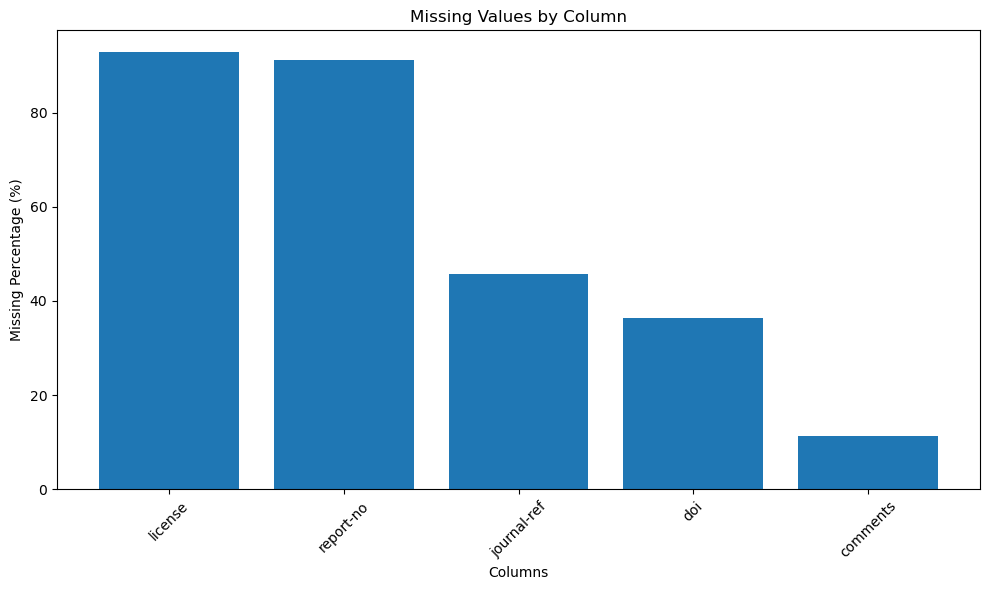

In [683]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

missing_percentage_filtered = missing_percentage[missing_percentage > 0]

plt.bar(
    missing_percentage_filtered.index,
    missing_percentage_filtered.values
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

#### Observations

- The `license` column has the highest percentage of missing values (92.87%).
- The `report-no` column is also largely incomplete (91.17%).
- Core metadata such as `title`, `authors`, `categories`, and `abstract` contain no missing values.
- The dataset is suitable for category and text analysis but some metadata fields may require cleaning or exclusion.

### Visualize how many papers were updated each year

In [419]:
converted_date = pd.to_datetime(df["update_date"])

papers_per_year = converted_date.dt.year.value_counts().sort_index()
papers_per_year

update_date
2007    3073
2008    2061
2009    3033
2010     354
2011     322
2012     150
2013      82
2014     118
2015     302
2016     180
2017      46
2018      28
2019     129
2020      18
2021      14
2022      14
2023       9
2024       6
2025       9
2026      52
Name: count, dtype: int64

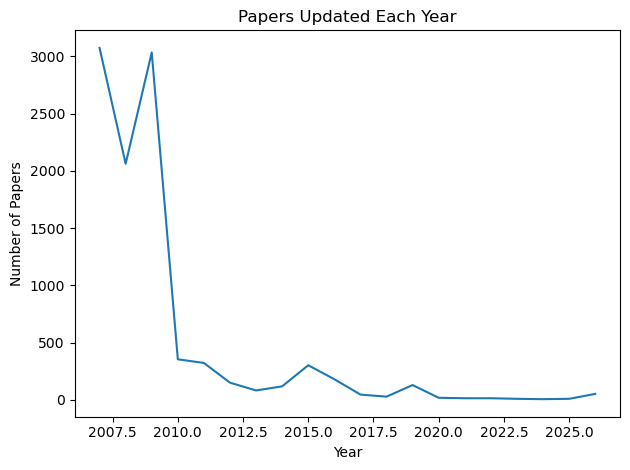

In [443]:
plt.plot(
    papers_per_year.index,
    papers_per_year.values,
)

plt.title("Papers Updated Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.tight_layout()

plt.show()

### Visualize how many papers were published each year

In [531]:
pub_date = pd.to_datetime(
    df["versions"].apply(lambda x: x[0] ["created"])
)

pub_date

0      2007-04-02 19:18:42
1      2007-03-31 02:26:18
2      2007-04-01 20:46:54
3      2007-03-31 03:16:14
4      2007-04-02 18:09:58
               ...        
9995   2007-06-09 13:10:18
9996   2007-06-09 13:20:57
9997   2007-06-11 19:21:33
9998   2007-06-09 14:38:18
9999   2007-06-09 15:09:52
Name: versions, Length: 10000, dtype: datetime64[ns]

In [536]:
pub_date.dt.year.value_counts()

versions
2007    10000
Name: count, dtype: int64

In [532]:
df["update_date"].min(), df["update_date"].max()

(Timestamp('2007-05-23 00:00:00'), Timestamp('2026-06-09 00:00:00'))

In [535]:
pub_date.min(), pub_date.max()

(Timestamp('2007-03-31 02:26:18'), Timestamp('2007-06-11 19:21:33'))

#### Observation

- The first 10,000 records in the dataset all correspond to papers initially submitted in 2007.
- This indicates that the dataset is ordered chronologically rather than randomly.
- Consequently, this sample cannot be used to analyze publication trends across multiple years.

### Visualize Top 10 Categories

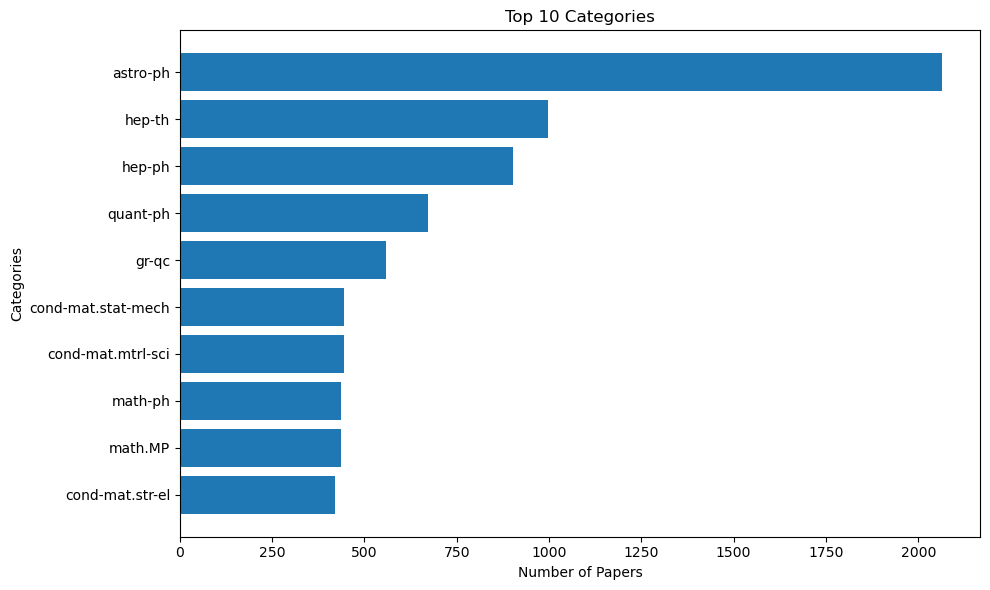

In [832]:
top_categories = df["categories"].str.split().explode().value_counts().head(10)

plt.figure(figsize= (10, 6))

plt.barh(
    top_categories.index, 
    top_categories.values
)

plt.gca().invert_yaxis()

plt.title("Top 10 Categories")
plt.xlabel("Number of Papers")
plt.ylabel("Categories")

plt.tight_layout()

plt.show()

#### Observations

- `astro-ph` is the most common category in the current sample.
- High-energy physics (`hep-ph`, `hep-th`) and quantum physics (`quant-ph`) are also among the most frequent categories.
- The sample is dominated by physics-related research areas.

### Visualize Top Authors

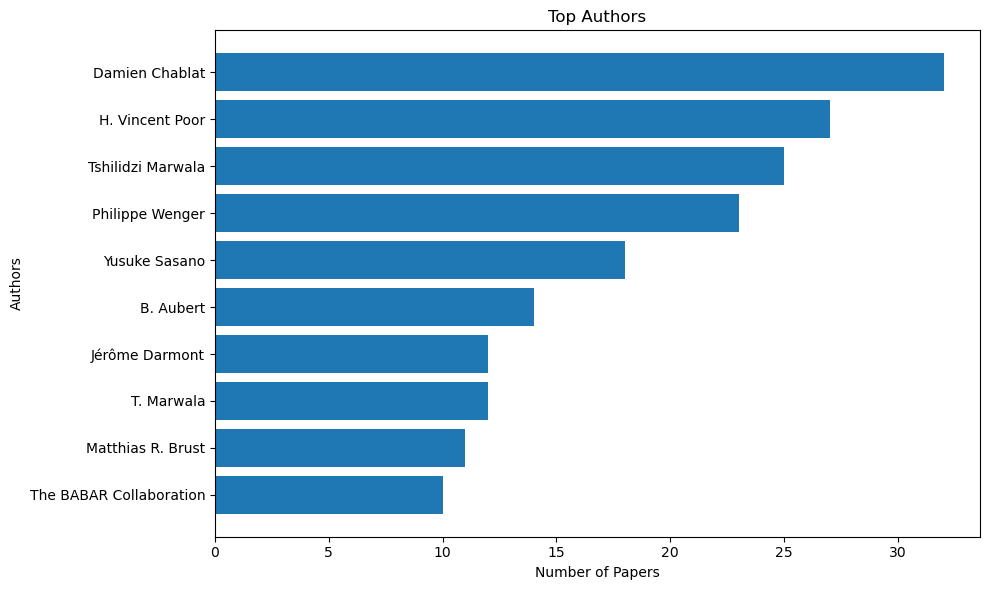

In [643]:
top_authors = df["authors_parsed"].explode().apply(lambda x: f"{x[1]} {x[0]}".strip()).value_counts().head(10)

plt.figure(figsize = (10, 6))

plt.barh(top_authors.index, top_authors.values)

plt.title("Top Authors")
plt.xlabel("Number of Papers")
plt.ylabel("Authors")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Visualize number of versions per paper

In [672]:
versions_per_paper = df["versions"].apply(lambda x : len(x))

versions_per_paper

0       2
1       2
2       3
3       1
4       1
       ..
9995    2
9996    1
9997    4
9998    1
9999    1
Name: versions, Length: 10000, dtype: int64

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


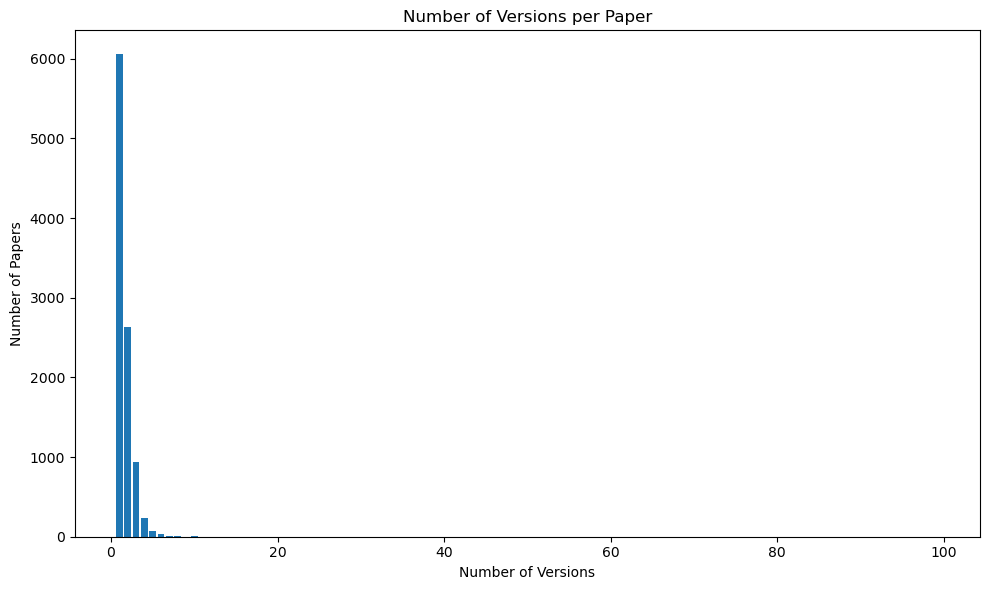

In [761]:
version_counts = versions_per_paper.value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    version_counts.index,
    version_counts.values
)

plt.title("Number of Versions per Paper")
plt.xlabel("Number of Versions")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

# Text analysis

### What is the maximum number of versions any paper has?

In [762]:
versions_per_paper.max()

99

### What is the average number of versions per paper?

In [763]:
versions_per_paper.mean()

np.float64(1.6049)

### Abstract length analysis

In [764]:
abstract_length = df["abstract"].apply(len)

abstract_length

0        983
1        798
2        880
3        248
4        223
        ... 
9995     684
9996     441
9997     507
9998    1153
9999     401
Name: abstract, Length: 10000, dtype: int64

### Title length analysis

In [768]:
title_length = df["title"].apply(len)

title_length
title_length.describe()

count    10000.000000
mean        70.228900
std         26.871191
min          8.000000
25%         51.000000
50%         66.000000
75%         86.000000
max        231.000000
Name: title, dtype: float64

### Most common words in titles

In [766]:
df["title"].str.split().explode().value_counts().head(20)

title
of         5787
the        3664
in         3300
and        3161
for        1488
a          1303
with        974
on          904
The         877
A           687
to          635
from        496
at          477
On          412
quantum     349
Quantum     307
by          289
model       229
an          224
Theory      170
Name: count, dtype: int64

### Most common words in abstracts

In [767]:
df["abstract"].str.split().explode().value_counts().head(20)

abstract
the     88215
of      58247
and     29099
a       28996
in      23151
to      22077
is      18559
for     12812
that    12365
with    11872
We      11583
The     10033
are      9456
by       8186
on       8090
we       7270
as       5962
an       5891
be       5830
this     5463
Name: count, dtype: int64

# Feature Analysis

In [862]:
df["abstract_length"] = df["abstract"].str.len()

df["title_length"] = df["title"].str.len()

df["num_authors"] = df["authors_parsed"].apply(len)

df["publication_year"] = pub_date.dt.year

df["num_versions"] = df["versions"].apply(len)

In [827]:
df["num_versions"].describe()

count    10000.000000
mean         1.604900
std          1.541374
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         99.000000
Name: num_versions, dtype: float64

In [835]:
version_counts = df["num_versions"].value_counts().sort_index()

version_counts

num_versions
1     6054
2     2637
3      943
4      235
5       77
6       29
7        8
8        6
9        2
10       3
11       1
13       2
34       1
71       1
99       1
Name: count, dtype: int64

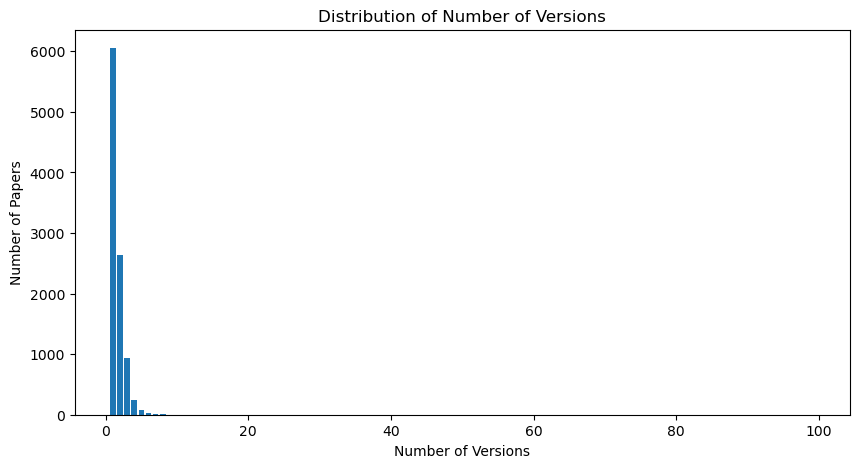

In [834]:
version_counts = df["num_versions"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.bar(
    version_counts.index,
    version_counts.values
)

plt.title("Distribution of Number of Versions")
plt.xlabel("Number of Versions")
plt.ylabel("Number of Papers")

plt.show()

### Findings

- Most papers have only one published version.
- The number of papers decreases rapidly as the version count increases.
- A small number of papers have unusually high numbers of revisions.

In [836]:
df["abstract_length"].describe()

count    10000.000000
mean       800.458200
std        405.042606
min         20.000000
25%        506.000000
50%        726.000000
75%       1038.250000
max       1875.000000
Name: abstract_length, dtype: float64

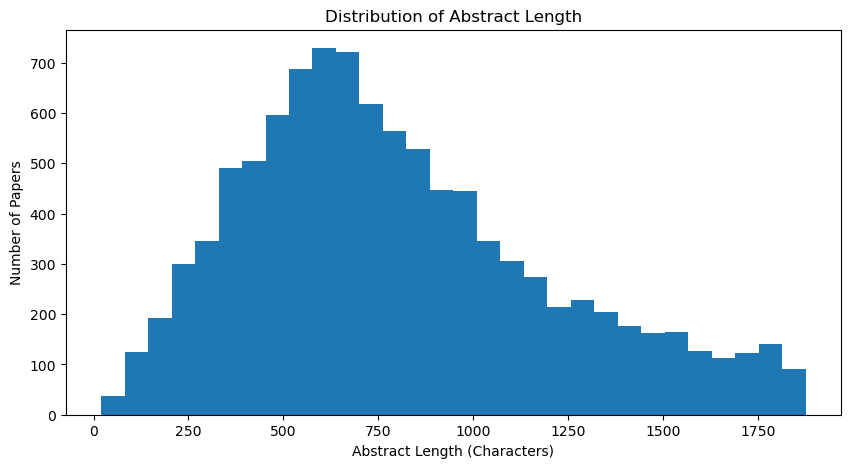

In [847]:
plt.figure(figsize=(10,5))

plt.hist(df["abstract_length"], bins=30)

plt.title("Distribution of Abstract Length")

plt.xlabel("Abstract Length (Characters)")

plt.ylabel("Number of Papers")

plt.show()

### Findings

- Most abstracts fall between approximately 500 and 1000 characters.
- Extremely short and extremely long abstracts are relatively uncommon.

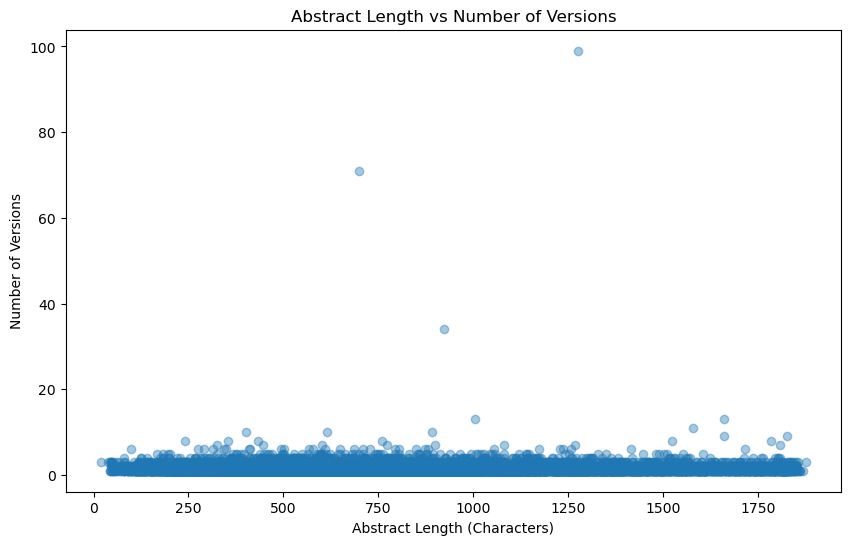

In [842]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["abstract_length"],
    df["num_versions"],
    alpha=0.4
)

plt.title("Abstract Length vs Number of Versions")
plt.xlabel("Abstract Length (Characters)")
plt.ylabel("Number of Versions")

plt.show()

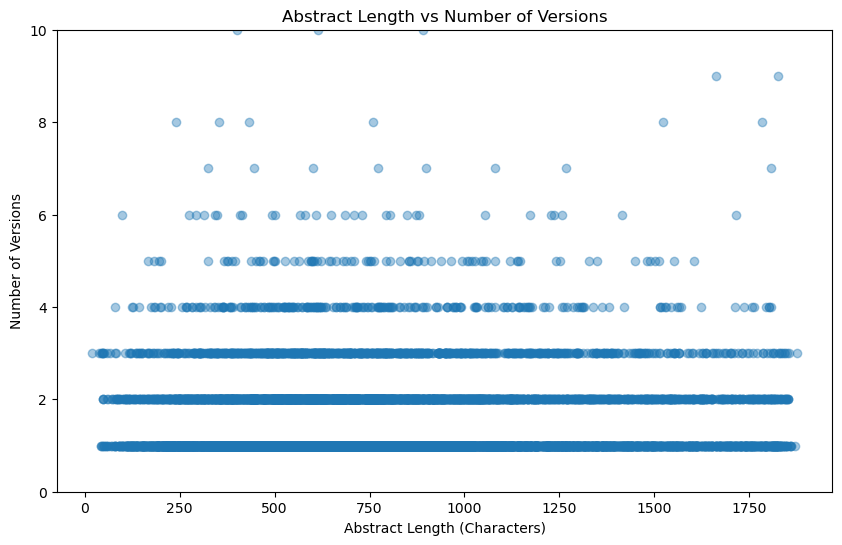

In [852]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["abstract_length"],
    df["num_versions"],
    alpha=0.4
)

plt.ylim(0, 10)

plt.title("Abstract Length vs Number of Versions")
plt.xlabel("Abstract Length (Characters)")
plt.ylabel("Number of Versions")

plt.show()

In [853]:
df[["abstract_length", "num_versions"]].corr()

,abstract_length,num_versions
abstract_length,1.000000,0.005693
num_versions,0.005693,1.000000


In [854]:
df["num_authors"].describe()

count    10000.000000
mean         3.137200
std          3.935165
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         99.000000
Name: num_authors, dtype: float64

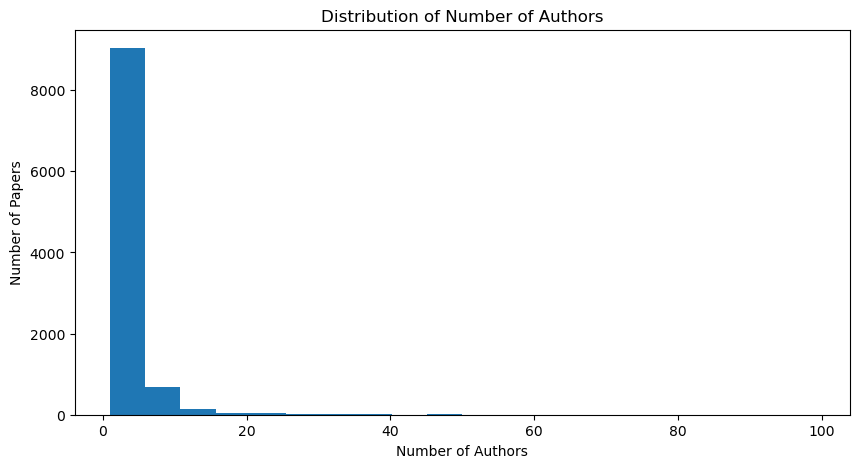

In [858]:
plt.figure(figsize=(10,5))

plt.hist(df["num_authors"], bins=20)

plt.title("Distribution of Number of Authors")
plt.xlabel("Number of Authors")
plt.ylabel("Number of Papers")

plt.show()

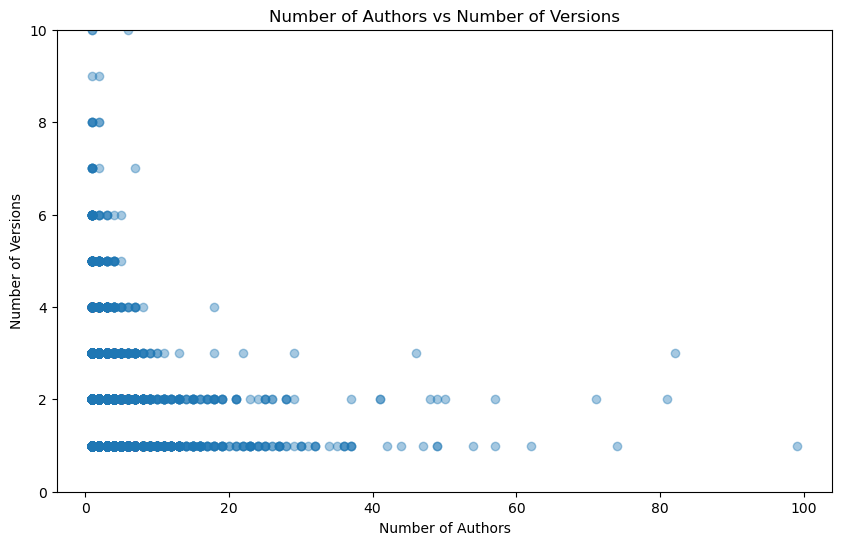

In [859]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["num_authors"],
    df["num_versions"],
    alpha=0.4
)

plt.title("Number of Authors vs Number of Versions")
plt.xlabel("Number of Authors")
plt.ylabel("Number of Versions")

plt.ylim(0,10)

plt.show()

In [860]:
df[["num_authors", "num_versions"]].corr()

,num_authors,num_versions
num_authors,1.00000,-0.04793
num_versions,-0.04793,1.00000


In [866]:
features = df[
    [
        "abstract_length",
        "title_length",
        "num_authors",
        "publication_year",
        "num_versions"
    ]
]

features.corr()

,abstract_length,title_length,num_authors,publication_year,num_versions
abstract_length,1.000000,0.228974,0.180795,NaN,0.005693
title_length,0.228974,1.000000,0.118189,NaN,-0.026949
num_authors,0.180795,0.118189,1.000000,NaN,-0.047930
publication_year,NaN,NaN,NaN,NaN,NaN
num_versions,0.005693,-0.026949,-0.047930,NaN,1.000000


### Findings

- Abstract length shows almost no linear relationship with paper versions.
- Number of authors also has a very weak relationship with paper versions.
- Publication year cannot be evaluated because the sample only contains papers from 2007.